# Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aesthetic defaults — set once, applied everywhere
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120


# ── Load & Prepare Data ─────────────────────────────────────────────────────
df = pd.read_csv("../data/mercari_sample.csv")


# --- Cleaning ---
df["brand_name"] = df["brand_name"].fillna("No Brand")
df = df.dropna(subset=["category_name"])
df = df[df["price"] > 0].copy()

# --- Feature Engineering ---
df["main_category"]    = df["category_name"].str.split("/").str[0]
df["sub_category"]     = df["category_name"].str.split("/").str[1]
df["sub_sub_category"] = df["category_name"].str.split("/").str[2]

condition_map = {1: "New", 2: "Like New", 3: "Good", 4: "Fair", 5: "Poor"}
df["condition_label"] = df["item_condition_id"].map(condition_map)

df["name_length"]      = df["name"].str.len()
df["log_price"]        = np.log1p(df["price"])
df["brand_name"]       = df["brand_name"].str.lower().str.strip()
df["has_description"]  = df["item_description"].apply(
    lambda x: 0 if x == "No description yet" else 1
)

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Categories: {df['main_category'].nunique()} | Brands: {df['brand_name'].nunique():,}")

Dataset: 49,725 rows × 15 columns
Categories: 10 | Brands: 1,529


In [12]:
# ── Design Tokens — change here, updates every chart ─────────────────────────
COLORS = {
    "primary"  : "#4F46E5",   # Indigo
    "secondary": "#0EA5E9",   # Sky blue
    "accent"   : "#F59E0B",   # Amber
    "positive" : "#10B981",   # Emerald
    "negative" : "#EF4444",   # Red
    "neutral"  : "#6B7280",   # Slate gray
}

In [13]:
# ── Shared Styling Helper ─────────────────────────────────────────────────────
def style_ax(ax, title, xlabel, ylabel, rotate_x=False):
    """Apply consistent chart styling: no top/right spines, soft grid, bold title."""
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, color="gray", linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=9)
    if rotate_x:
        ax.tick_params(axis="x", rotation=45)

---
## 📊 Chart A — Why We Use Log Price

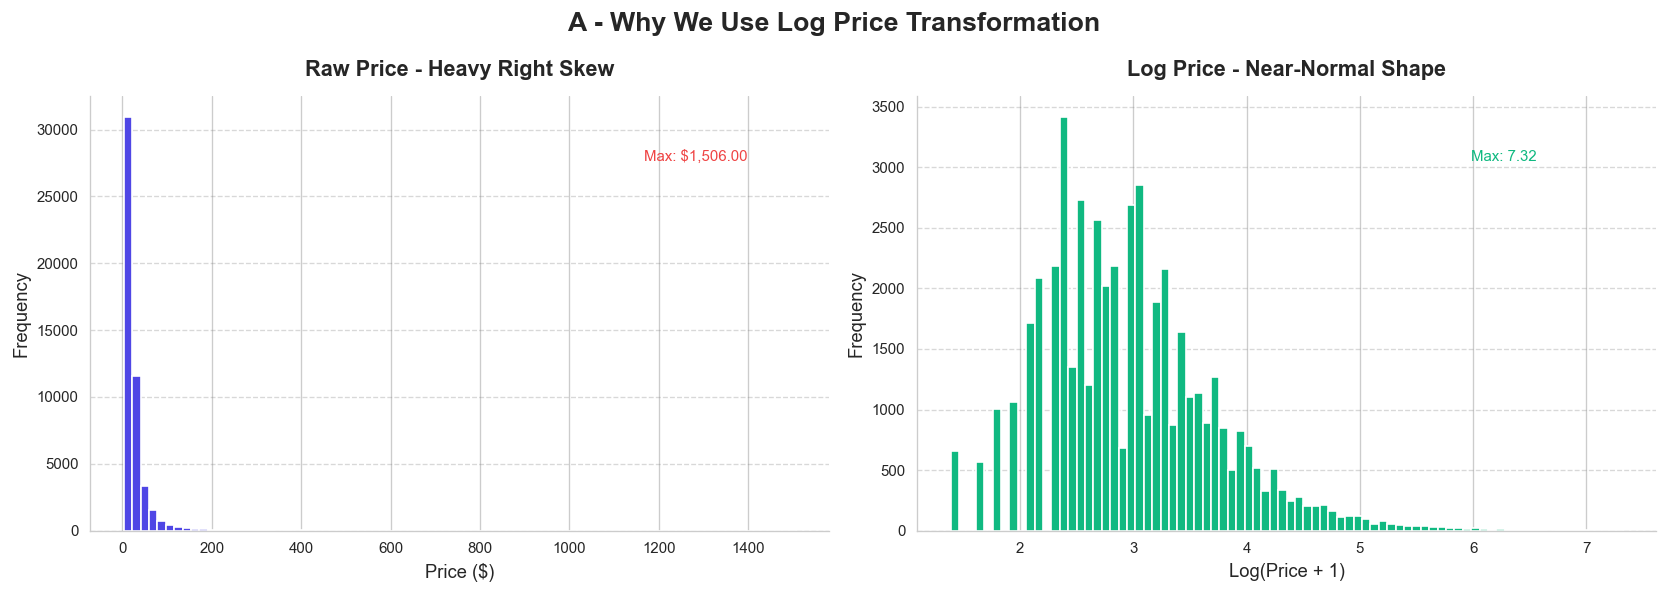

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"], bins=80, color=COLORS["primary"], edgecolor="white")
style_ax(axes[0], "Raw Price - Heavy Right Skew", "Price ($)", "Frequency")
axes[0].annotate(f"Max: ${df['price'].max():,.2f}", xy=(0.75, 0.85), xycoords="axes fraction",
                  fontsize=9, color=COLORS["negative"])

axes[1].hist(df["log_price"], bins=80, color=COLORS["positive"], edgecolor="white")
style_ax(axes[1], "Log Price - Near-Normal Shape", "Log(Price + 1)", "Frequency")    
axes[1].annotate(f"Max: {df['log_price'].max():.2f}", xy=(0.75, 0.85), xycoords="axes fraction",
                  fontsize=9, color=COLORS["positive"])

fig.suptitle("A - Why We Use Log Price Transformation", fontsize=16, fontweight="bold")
plt.savefig("../charts/A_price_distribution.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

**Question:** Price is right-skewed — how does log transformation fix that?  
**Insight:** Raw price is dominated by a long right tail (a few $1,500 luxury items). `log1p` compresses the range from 0–1506 → 0–7.3, producing a near-normal distribution that gradient-based models train on far more efficiently.

---
## 📊 Chart B — Volume vs Value by Category

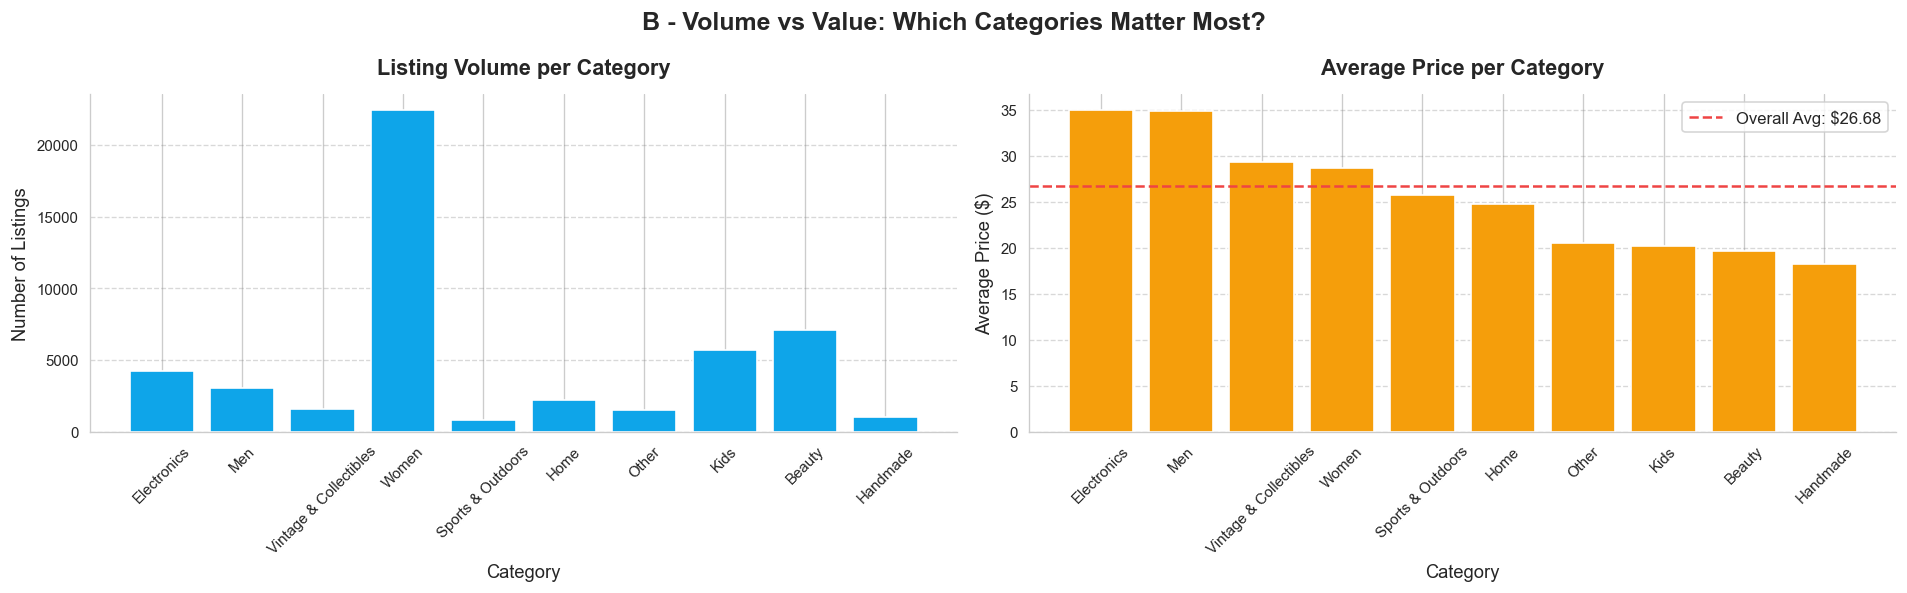

In [15]:
cat_stats = (
    df.groupby("main_category")["price"]
    .agg(count="count", avg_price="mean")
    .sort_values("avg_price", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(cat_stats.index, cat_stats["count"],
            color=COLORS["secondary"], edgecolor="white")
style_ax(axes[0], "Listing Volume per Category", 
         "Category", "Number of Listings", rotate_x=True)

axes[1].bar(cat_stats.index, cat_stats["avg_price"], 
            color=COLORS["accent"], edgecolor="white")
overall_avg = df["price"].mean()
axes[1].axhline(overall_avg, color=COLORS["negative"], 
                linestyle="--", label=f"Overall Avg: ${overall_avg:.2f}")
axes[1].legend()
style_ax(axes[1], "Average Price per Category", 
         "Category", "Average Price ($)", rotate_x=True)

fig.suptitle("B - Volume vs Value: Which Categories Matter Most?",
              fontsize=15, fontweight="bold")
plt.savefig("../charts/B_category_volume_vs_value.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

**Question:** Which categories have the most listings, and which command the highest prices?  
**Insight:** Women dominates listing volume (≈45% of all items) but Electronics wins on average price. A platform serving volume ≠ a platform serving value — Mercari needs different strategies for each.

## 📊 Chart C — Does Condition Predict Price?

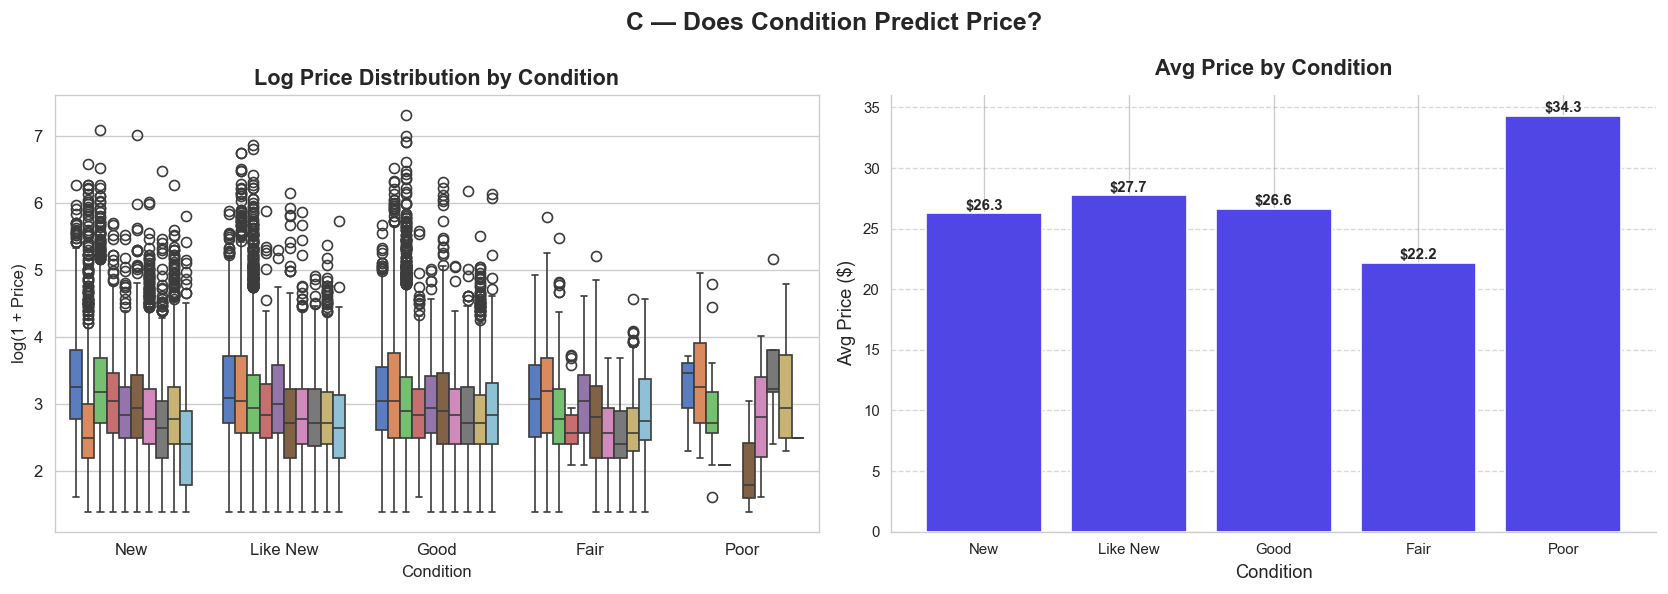

In [16]:
condition_order = ["New", "Like New", "Good", "Fair", "Poor"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution by condition
sns.boxplot(data=df, x="condition_label", y="log_price",
            order=condition_order,
            hue="main_category", palette="muted",
            legend=False, ax=axes[0])
axes[0].set_title("Log Price Distribution by Condition", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("log(1 + Price)")

# Right: mean price bar for quick comparison
condition_avg = df.groupby("condition_label")["price"].mean().reindex(condition_order)
axes[1].bar(condition_avg.index, condition_avg.values,
            color=COLORS["primary"], edgecolor="white")
style_ax(axes[1], "Avg Price by Condition", "Condition", "Avg Price ($)")

# Annotate each bar
for i, (label, val) in enumerate(condition_avg.items()):
    axes[1].text(i, val + 0.3, f"${val:.1f}", ha="center", fontsize=9, fontweight="bold")

fig.suptitle("C — Does Condition Predict Price?", fontsize=15, fontweight="bold")
plt.savefig("../charts/C_condition_vs_price.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

**Question:** Do buyers actually pay more for better-condition items?  
**Insight:** The relationship is non-linear. "Like New" items average *higher* than "New", possibly because sellers calibrate price to perceived value. "Poor" averages highest — suggesting rare collectibles in worn condition still attract premium bids.

---
## 📊 Chart D — Shipping Behaviour Reveals Seller Strategy

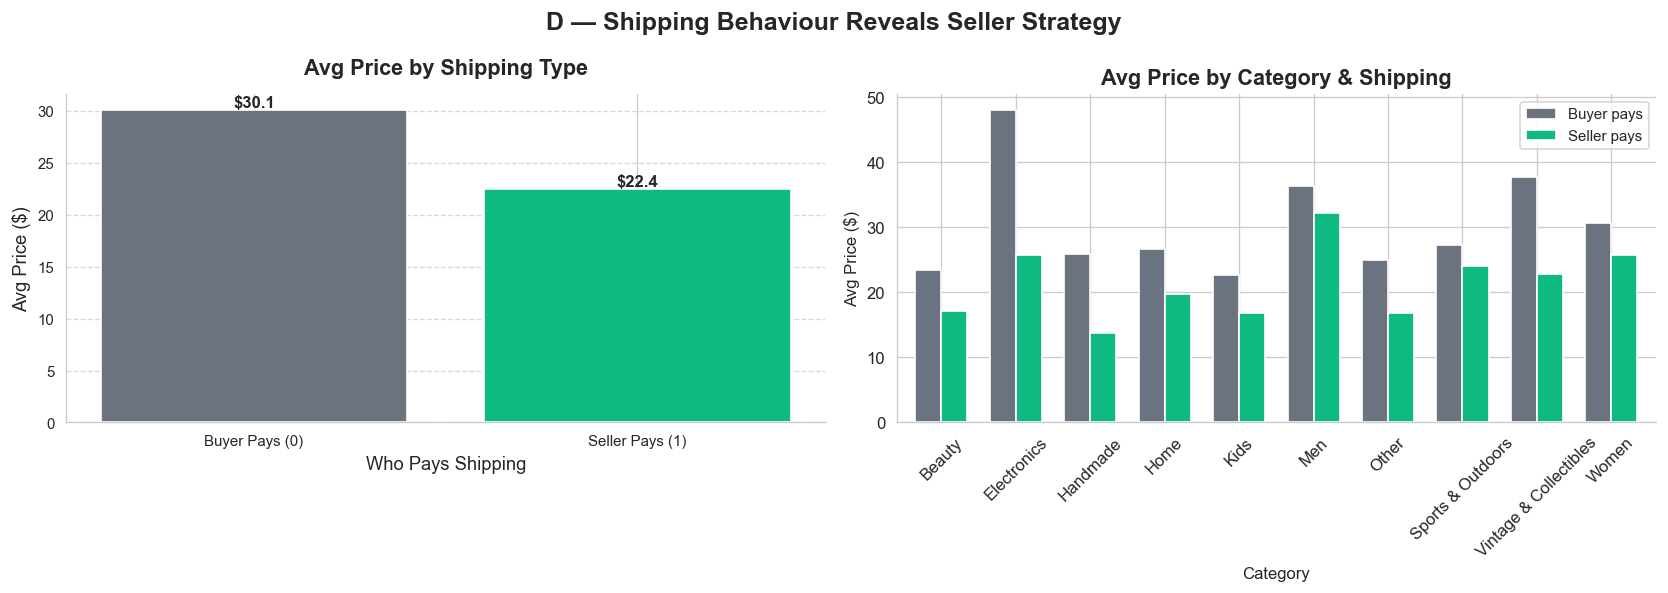

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shipping_avg = df.groupby("shipping")["price"].mean()
axes[0].bar(["Buyer Pays (0)", "Seller Pays (1)"],
            shipping_avg.values,
            color=[COLORS["neutral"], COLORS["positive"]],
            edgecolor="white")
style_ax(axes[0], "Avg Price by Shipping Type", "Who Pays Shipping", "Avg Price ($)")
for i, v in enumerate(shipping_avg.values):
    axes[0].text(i, v + 0.3, f"${v:.1f}", ha="center", fontsize=10, fontweight="bold")

shipping_cat = (
    df.groupby(["main_category", "shipping"])["price"]
    .mean().unstack().round(2)
)
shipping_cat.plot(kind="bar", ax=axes[1],
                  color=[COLORS["neutral"], COLORS["positive"]], width=0.7)
axes[1].set_title("Avg Price by Category & Shipping", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Avg Price ($)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(["Buyer pays", "Seller pays"], fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("D — Shipping Behaviour Reveals Seller Strategy",
             fontsize=15, fontweight="bold")
plt.savefig("../charts/D_shipping_analysis.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

**Question:** Do items with seller-paid shipping list at a higher price to compensate?  
**Insight:** Items where the seller pays shipping consistently list higher — sellers are embedding the shipping cost into the ticket price. This is especially prominent in Electronics and Men's categories.

---
## 📊 Chart E — Feature Correlation Matrix

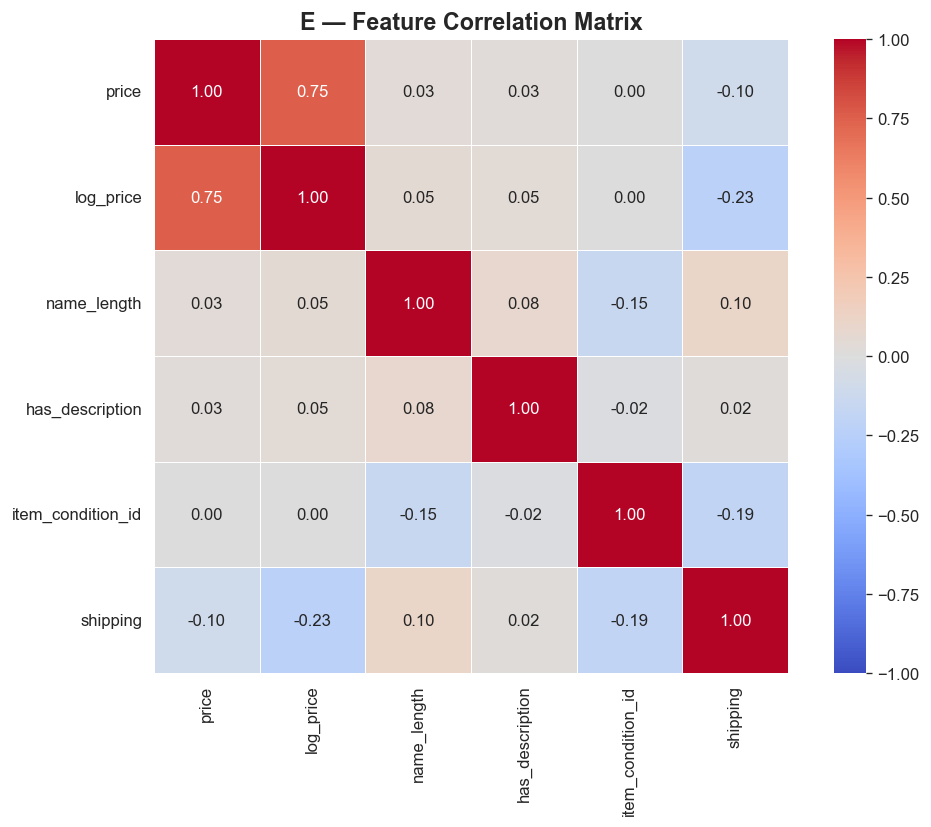

Top correlates with price:
log_price            0.752
shipping             0.100
name_length          0.033
has_description      0.028
item_condition_id    0.000
Name: price, dtype: float64


In [18]:
numeric_cols = ["price", "log_price", "name_length",
                "has_description", "item_condition_id", "shipping"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("E — Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.savefig("../charts/E_feature_correlation_heatmap.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

# Key takeaways
print("Top correlates with price:")
print(corr["price"].drop("price").abs().sort_values(ascending=False).round(3))

**Question:** Which features have the strongest linear relationship with price?  
**Insight:** `log_price` and `price` are perfectly correlated (by construction). `item_condition_id` has a slight negative correlation with price — lower condition IDs (1 = New) correspond to higher prices. `shipping` shows a positive correlation — seller-paid shipping tends to come with higher-priced listings.

---
## 📊 Chart F — Top Brands by Average Price

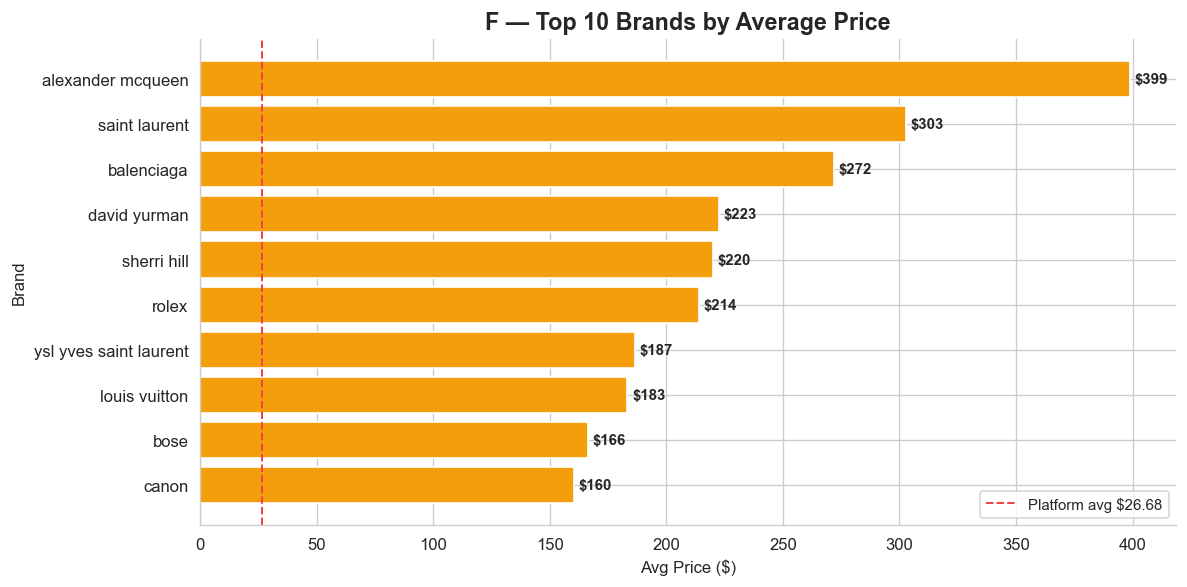

In [19]:
top_brands = (
    df[df["brand_name"] != "no brand"]
    .groupby("brand_name")
    .filter(lambda x: len(x) >= 3)   # require at least 3 listings for statistical credibility
    .groupby("brand_name")["price"]
    .mean()
    .nlargest(10)
    .round(2)
    .sort_values()                    # ascending for horizontal bar readability
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_brands.index, top_brands.values,
               color=COLORS["accent"], edgecolor="white")

for bar, val in zip(bars, top_brands.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=9, fontweight="bold")

ax.set_title("F — Top 10 Brands by Average Price", fontsize=14, fontweight="bold")
ax.set_xlabel("Avg Price ($)")
ax.set_ylabel("Brand")
ax.axvline(df["price"].mean(), color=COLORS["negative"],
           linestyle="--", linewidth=1.2, label=f"Platform avg ${df['price'].mean():.2f}")

ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig("../charts/F_top_brands.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

**Question:** Which brands command the highest average selling price on Mercari?  
**Insight:** Luxury labels (Celine, Canada Goose, Valentino) dominate the top 10 with average prices 5–20× the platform average of $26.66. These brands represent a high-value niche that warrants dedicated seller-acquisition campaigns.